<a href="https://colab.research.google.com/github/benchcodes/COM242_CCMACLRL/blob/main/Culubong_Exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [29]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("personality_dataset.csv")

Saving personality_dataset.csv to personality_dataset (2).csv


In [30]:
df['Stage_fear'] = df['Stage_fear'].map({'Yes': 1, 'No': 0})
df['Drained_after_socializing'] = df['Drained_after_socializing'].map({'Yes': 1, 'No': 0})

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [31]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,1,6,7,0,14,5,Extrovert
1,2,0,8,6,0,7,8,Extrovert
2,1,0,9,4,0,9,3,Extrovert
3,8,0,0,0,1,9,3,Introvert
4,5,1,3,0,0,2,6,Introvert


Display the summary of all the features of the dataset using `.info()`

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   int64 
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   int64 
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(7), object(1)
memory usage: 312.6+ KB


Display the total number of samples from each label using `.value_counts()`

In [33]:
df["Personality"].value_counts()

,count
Personality,
Introvert,2502
Extrovert,2498


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

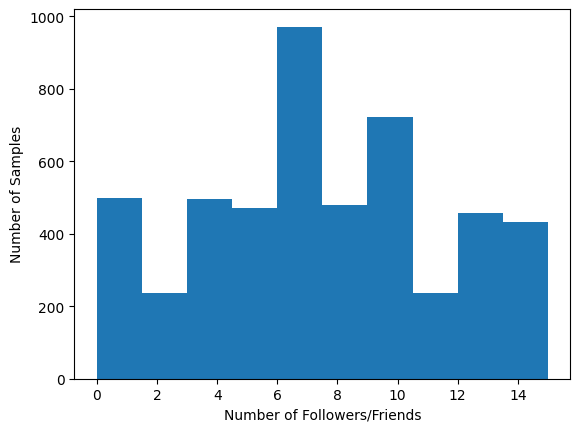

In [34]:
plt.hist(df['Friends_circle_size'])
plt.xlabel('Number of Followers/Friends')
plt.ylabel('Number of Samples')
plt.show()

Remove the name column using `drop()` method

In [35]:
#Nothing to remove

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [36]:
X = df.drop("Personality", axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [37]:
y = df["Personality"].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Display the dimensions of each variables using `.shape()`

In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 7)
(1000, 7)
(4000,)
(1000,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [40]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [41]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [42]:
y_pred = knn.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

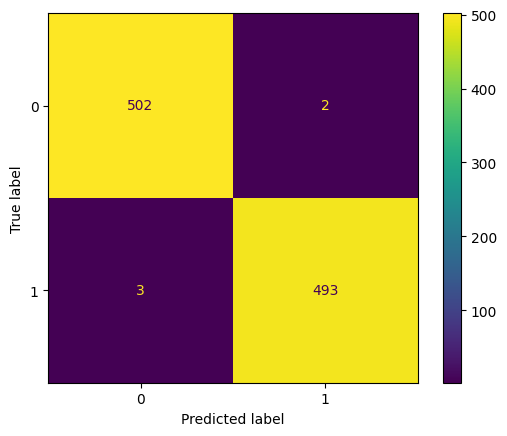

In [43]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Display the accuracy

In [44]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.995


Display the precision

In [45]:
precision = precision_score(y_test, y_pred, pos_label='Extrovert')
print(precision)

0.994059405940594


Display the recall

In [46]:
recall = recall_score(y_test, y_pred, pos_label='Extrovert')
print(recall)

0.996031746031746


Display the f1-score

In [47]:
f1 = f1_score(y_test, y_pred, pos_label='Extrovert')
print(f1)

0.9950445986124876


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [48]:
my_data = [[8, 4, 7, 9, 0, 14, 5]]
prediction = knn.predict(my_data)

if prediction[0] == 'Introvert':
    print("Predicted Personality: Introvert")
else:
    print("Predicted Personality: Extrovert")

Predicted Personality: Extrovert
